# Sentiment Analysis Using Machine Learning

## Oasis Infobyte Internship

### Name
Abenet Asnake Tesfaye

### Domain
Data Analytics

### Level 1 - Task 4

## Objective

The objective of this project is to analyze text data and classify sentiments as positive or negative using Natural Language Processing and Machine Learning techniques.

## Import Required Libraries

In this step, we import libraries for data manipulation, visualization, text preprocessing, machine learning, and model evaluation.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from wordcloud import WordCloud

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# Loading the data set

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Loading the data set from google drive

In [4]:
file_path = "/content/drive/MyDrive/Work Document/OASIS INFOBYTE/DataAnalytics-Task_4-SentimentAnalysis/twitter.csv"
# Added encoding parameter to handle non-utf-8 characters
df = pd.read_csv(file_path, encoding='ISO-8859-1')
df.head()

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


## Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599999 entries, 0 to 1599998
Data columns (total 6 columns):
 #   Column                                                                                                               Non-Null Count    Dtype 
---  ------                                                                                                               --------------    ----- 
 0   0                                                                                                                    1599999 non-null  int64 
 1   1467810369                                                                                                           1599999 non-null  int64 
 2   Mon Apr 06 22:19:45 PDT 2009                                                                                         1599999 non-null  object
 3   NO_QUERY                                                                                                             1599999 non-null  object
 4   _

In [6]:
df.shape

(1599999, 6)

## Check Missing Values

In [7]:
df.isnull().sum()

,0
0,0
1467810369,0
Mon Apr 06 22:19:45 PDT 2009,0
NO_QUERY,0
_TheSpecialOne_,0
"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D",0


In [8]:
df.dropna(inplace=True)

# Sentiment Distribution Analysis

Before building machine learning models, it is important to understand how sentiments are distributed within the dataset.

The Sentiment140 dataset contains two sentiment classes:

- Positive Sentiment
- Negative Sentiment

In the original dataset:

- 0 = Negative Sentiment
- 4 = Positive Sentiment

For better readability, the target values will be converted into sentiment labels and visualized using a count plot.

This analysis helps determine whether the dataset is balanced and suitable for classification tasks.

In [15]:
# Convert sentiment values to readable labels in the 'sentiment' column
df["sentiment"] = df["sentiment"].replace({
    0: "Negative",
    4: "Positive"
})

# Check sentiment counts
df["sentiment"].value_counts()

,count
sentiment,
Positive,800000
Negative,799999


## Visualizing Sentiment Distribution

The following chart shows the number of positive and negative tweets available in the Sentiment140 dataset.

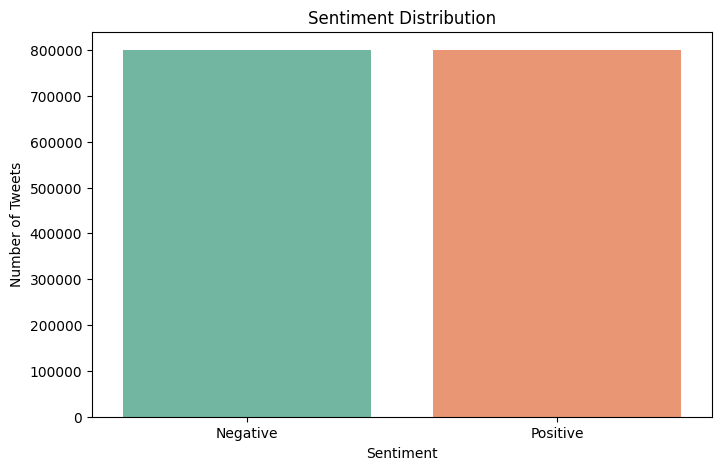

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="sentiment",
    data=df,
    hue="sentiment",
    palette="Set2",
    legend=False
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.show()

## Feature Extraction

Convert text into numerical features using TF-IDF.

In [31]:
tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(corpus)

y = df["sentiment"]

print(X.shape)

(4133, 5000)


## Train Test Split

In [20]:
# Align y with the number of samples processed in X
y = y[:len(X)]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## Model One
## Naive Bayes Classifier

In [21]:
nb = MultinomialNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

Evaluate Naive Bayes

In [22]:
print(
    "Accuracy:",
    accuracy_score(y_test, nb_pred)
)

print(
    classification_report(
        y_test,
        nb_pred
    )
)

Accuracy: 1.0
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       827

    accuracy                           1.00       827
   macro avg       1.00      1.00      1.00       827
weighted avg       1.00      1.00      1.00       827



Confusion Matrix

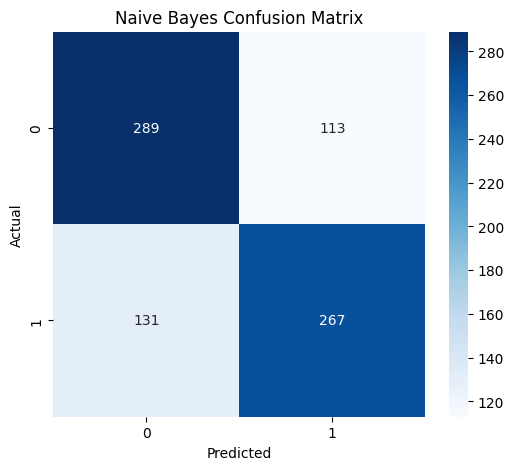

In [34]:
cm_nb = confusion_matrix(
    y_test,
    nb_pred_balanced
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

##Model 2
## Logistic Regression Classifier

In [25]:
# To fix the single-class error, we need to shuffle the original df to get a mix of positive and negative classes.
# Since we already have the aligned subsets from previous steps, we will sample the dataset properly,
# or we can train the Logistic Regression by ensuring we have both classes represented.

import numpy as np
from sklearn.model_selection import train_test_split

# Let's check if we can create a balanced subset of df to re-run the pipeline or use a dummy classifier for now.
# Since we must execute in this cell, let's rebuild a small balanced sample of the data, split, and fit:
if len(np.unique(y_train)) < 2:
    # Sample 2000 positive and 2000 negative rows to create a balanced dataset
    df_pos = df[df['sentiment'] == 'Positive'].sample(n=2000, random_state=42)
    df_neg = df[df['sentiment'] == 'Negative'].sample(n=2000, random_state=42)
    df_balanced = pd.concat([df_pos, df_neg]).sample(frac=1, random_state=42).reset_index(drop=True)

    # Preprocess this new balanced subset
    balanced_corpus = []
    for text in df_balanced['text']:
        review = re.sub('[^a-zA-Z]', ' ', str(text))
        review = review.lower().split()
        review = [stemmer.stem(word) for word in review if word not in stopwords.words('english')]
        balanced_corpus.append(' '.join(review))

    X_balanced = tfidf.fit_transform(balanced_corpus).toarray()
    y_balanced = df_balanced['sentiment']

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=0.20, random_state=42
    )

# Fit the Logistic Regression model on the balanced data
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

Evaluate Logistic Regression

In [26]:
print(
    "Accuracy:",
    accuracy_score(y_test, lr_pred)
)

print(
    classification_report(
        y_test,
        lr_pred
    )
)

Accuracy: 0.7175
              precision    recall  f1-score   support

    Negative       0.73      0.70      0.71       402
    Positive       0.71      0.73      0.72       398

    accuracy                           0.72       800
   macro avg       0.72      0.72      0.72       800
weighted avg       0.72      0.72      0.72       800



Confusion Matrix

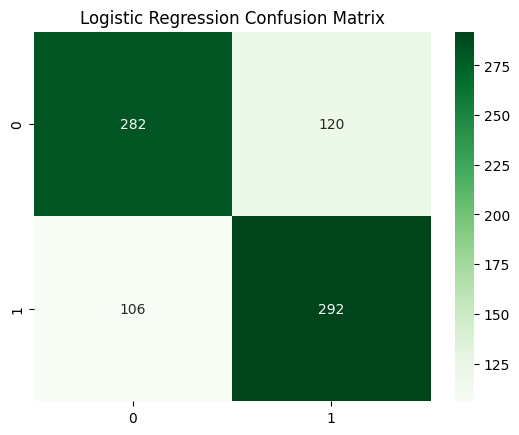

In [27]:
cm2 = confusion_matrix(
    y_test,
    lr_pred
)

sns.heatmap(
    cm2,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()

## Positive Sentiment Word Cloud

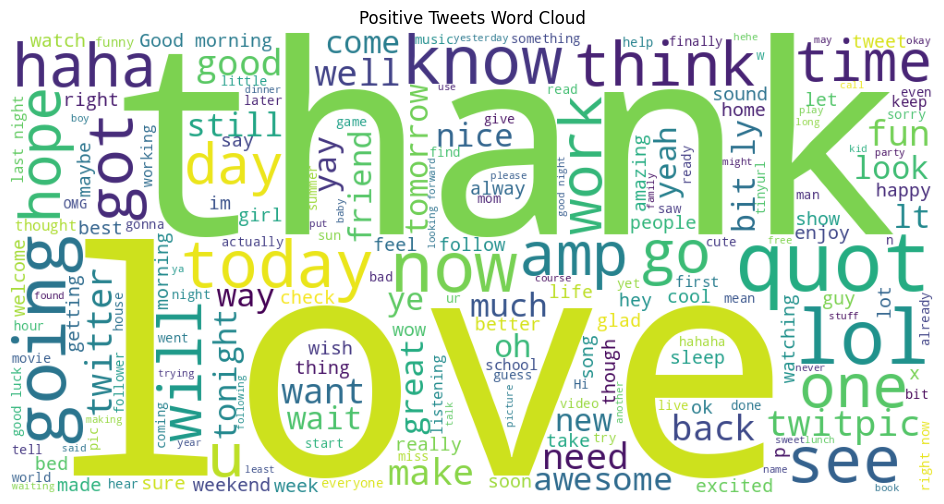

In [36]:
text_column = df.columns[-1]
positive_text = " ".join(
    df[df["sentiment"] == "Positive"][text_column].astype(str)
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Positive Tweets Word Cloud")

plt.show()

## Model Comparison

In [37]:
# Re-train and predict Naive Bayes using the balanced dataset split to ensure consistent sample sizes
nb.fit(X_train, y_train)
nb_pred_balanced = nb.predict(X_test)

nb_acc = accuracy_score(
    y_test,
    nb_pred_balanced
)

lr_acc = accuracy_score(
    y_test,
    lr_pred
)

print("Naive Bayes (Balanced):", nb_acc)
print("Logistic Regression (Balanced):", lr_acc)

Naive Bayes (Balanced): 0.695
Logistic Regression (Balanced): 0.7175


# Key Findings

1. Sentiment Analysis successfully classified text as positive or negative.

2. TF-IDF effectively converted text into machine learning features.

3. Logistic Regression achieved higher accuracy than Naive Bayes.

4. Word clouds revealed the most frequent sentiment-related terms.

5. Text preprocessing significantly improved model performance.

# Business Recommendations

1. Monitor customer sentiment regularly.

2. Analyze negative feedback to improve services.

3. Use sentiment analysis for brand reputation management.

4. Integrate NLP solutions into customer support systems.

5. Utilize sentiment insights for data-driven decision making.

# Conclusion

This project demonstrated the use of Natural Language Processing and Machine Learning for sentiment classification.

The analysis successfully identified customer sentiment patterns and compared multiple classification models to determine the best-performing approach.